# 

# Praktische Anwendung der Bilinear-Transformation

Die analogen Biquad Filter für die Anwendung der Bilineartransformation werden aus dem Experiment 4 des Analog Systems Lab Kit PRO entnommen.

## Übertragungsfunktionen der analogen Biquad Filter

**Tiefpass:** $H_{TP}(s) = \frac{V_3}{V_i} = \frac{+H_0}{1 + \frac{s}{w_0Q} + \frac{s^2}{w_0^2}} = \frac{+H_0 \cdot w_0^2}{w_0^2 + \frac{sw_0}{Q} + s^2}$

**Hochpass:** $H_{HP}(s) = \frac{V_1}{V_i} = \frac{H_0 \cdot \frac{s^2}{w_0^2}}{1 + \frac{s}{w_0Q} + \frac{s^2}{w_0^2}} = \frac{+H_0 \cdot s^2}{w_0^2 + \frac{sw_0}{Q} + s^2}$

**Bandpass:** $H_{BP}(s) = \frac{V_2}{V_i} = \frac{-H_0 \cdot \frac{s}{w_0}}{1 + \frac{s}{w_0Q} + \frac{s^2}{w_0^2}} = \frac{-H_0 \cdot sw_0}{w_0^2 + \frac{sw_0}{Q} + s^2}$

**Bandsperre:** $H_{BS}(s) = \frac{V_4}{V_i} = \frac{(1 + \frac{s^2}{w_0^2 \cdot}) \cdot H_0}{1 + \frac{s}{w_0Q} + \frac{s^2}{w_0^2}} = \frac{(w_0^2 + s^2) \cdot H_0}{w_0^2 + \frac{sw_0}{Q} + s^2}$

## Analoge Filterschaltung

<figure>
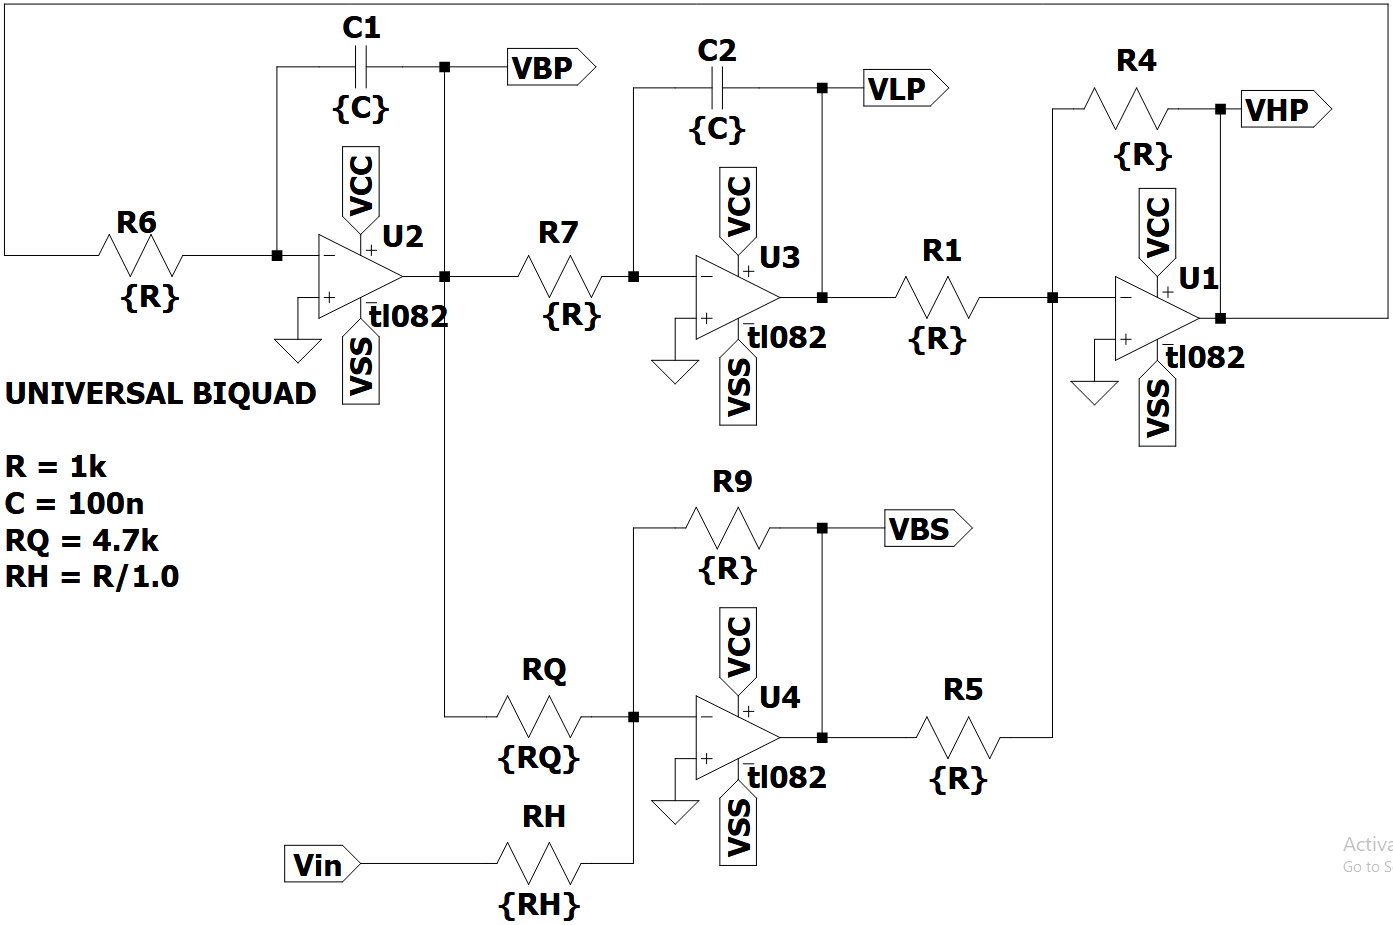
<figcaption aria-hidden="true">Analoge Biquad Schaltung</figcaption>
</figure>

Um diese analogen Filter Bilinear zu transformieren stehen MATLAB sowie Python zur Verfügung, um die Durchführung der Substitutionen durchzuführen.

## Python

Python mit scipy.signal

``` python
numz, denz = bilinear(nums ,dens ,fs = fs)
```

``` python
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqs, bilinear, freqz
```

Für die Bilinear-Transformation wird die Scipy-Bibliothek mit dem Signal-Modul verwendet. Aus diesem Modul werden die Funktionen freqs, bilinear und freqz importiert. Für weitere Berechnungen wird Numpy als np importiert und für die Möglichkeit zum Plotten wird Matplotlib.pyplot als plt importiert.

``` python
R = 1000
C = 100e-9
w0 = 1 / (R * C)
Q = 4.7
fs = 44100
```

Aus dem Schaltbild der analogen Filterschaltung werden dessen Parameter entnommen. Die Kreisfrequenz $w_0$ berechnet sich durch $w_0 = \frac{1}{R C}$. Der Wert $H_0$ beschreibt den Gainfaktor der Filterschaltungen und wird auf 1 gesetzt, wodurch dieser nicht mehr im Code aufkommt. Die digitalen Filter sollen für Audioanwendungen verwendet werden, weshalb die Wahl von 44,1 kHz als Abtastfrequenz getroffen wurde. Durch die Wahl der Abtastefrequenz von 44,1 kHz wird kein Prewarping benötigt, da die Frequenzverzerrung vernachlässigbar ist.

``` python
# Tiefpass Zähler
TP_nums = [0, 0, w0**2]

# Hochpass Zähler
HP_nums = [1, 0, 0]

# Bandpass Zähler
BP_nums =  [0, -w0, 0]

# Bandstop Zähler
BS_nums = [1, 0, w0**2]

# Nenner
dens = [1, w0/Q, w0**2]
```

Die Zähler und Nenner der Übertragungsfunktionen der analogen Filter werden als Listen übernommen. Die Listenelemente entsprechen den Koeffizienten in absteigender Potenzordnung: $[s^2, s^1, s^0]$. Die Nenner der vier Filter sind identisch und müssen nur einmal übernommen werden.

``` python
# Bilineartransformation

# Tiefpass
TP_numz, TP_denz = bilinear(TP_nums, dens, fs = fs)

# Hochpass
HP_numz, HP_denz = bilinear(HP_nums, dens, fs = fs)

# Bandpass
BP_numz, BP_denz = bilinear(BP_nums, dens, fs = fs)

# Bandstop
BS_numz, BS_denz = bilinear(BS_nums, dens, fs = fs)
```

Die Bilineartransformation wird durch `bilinear` durchgeführt, indem dieser Funktion die Zähler- und Nennerlisten der jeweiligen Filter mit der Abtastfrequenzen $f_s$ übergeben werden. Die Funktion liefert die Zähler- und Nennerkoeffizienten der digitalen Übertragungsfunktion.

<figure>
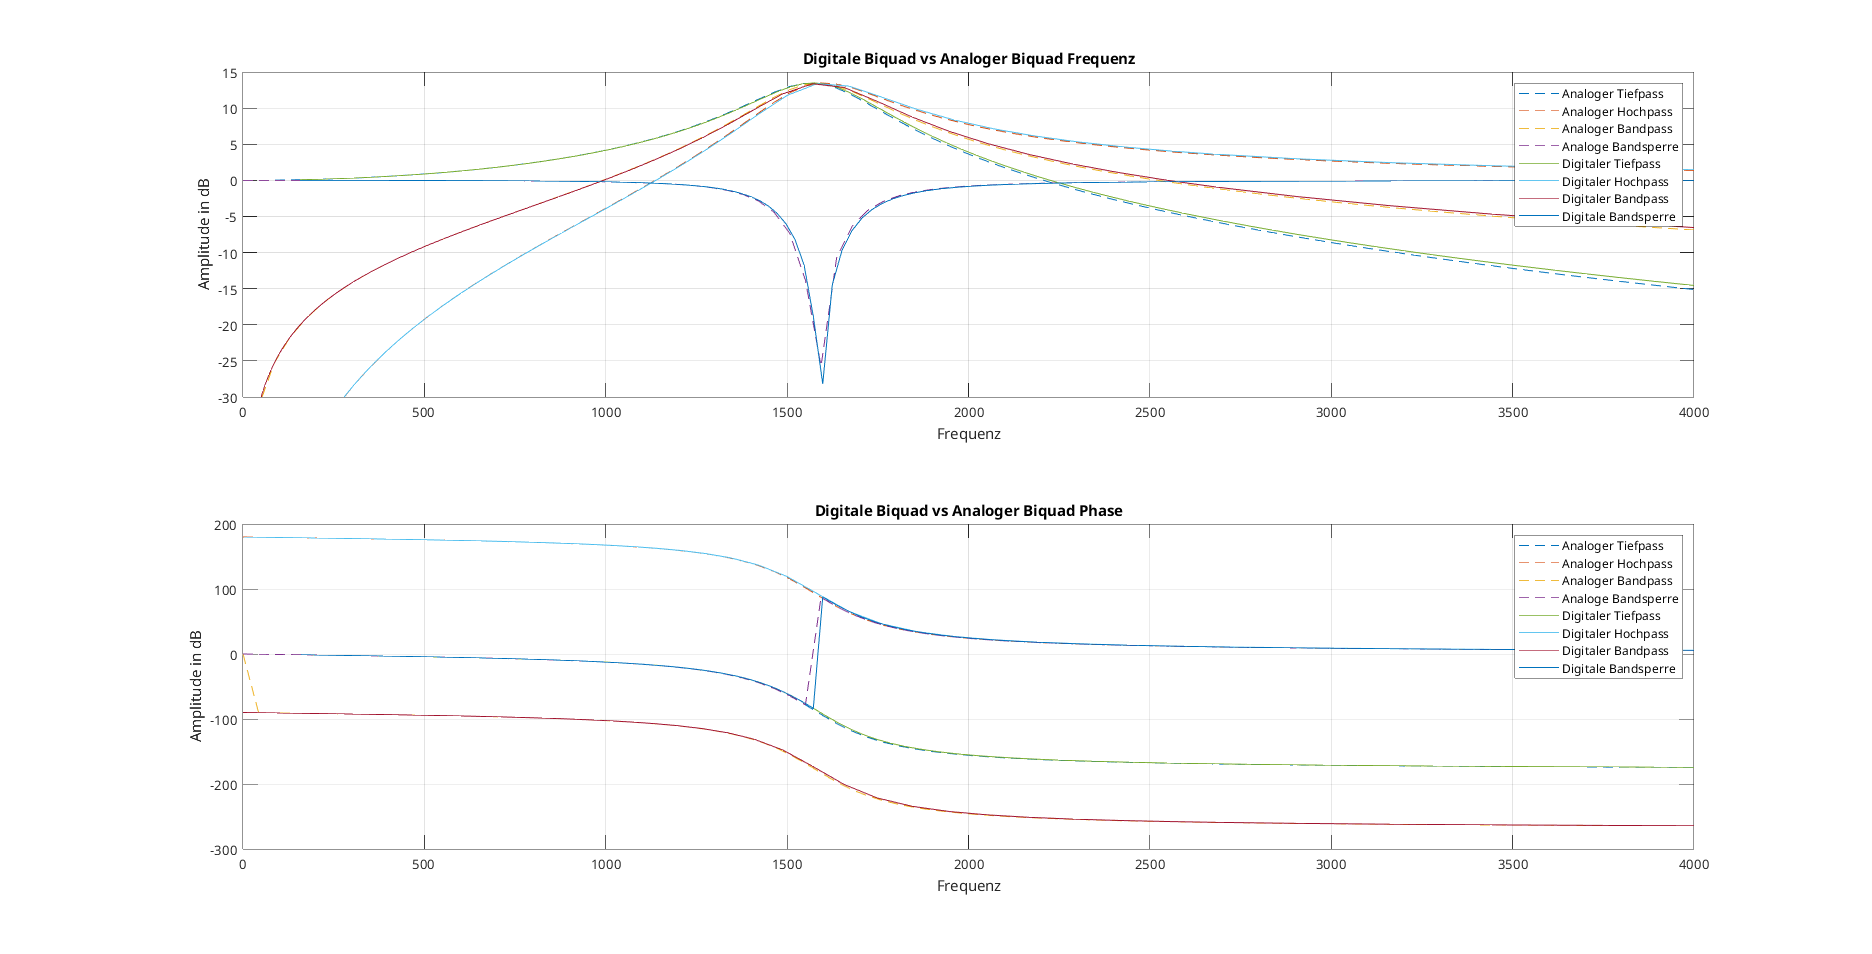
<figcaption aria-hidden="true">Vergleich zwischen analogen und digitalen Frequenz- und Phasengang</figcaption>
</figure>

## MATLAB

``` matlab
[numz, denz] = bilinear(nums ,dens ,fs ,fp)
```

Der Prozess der Bilinear-Transformation in MATLAB ist vom Verlauf identisch zu dem in Python, jedoch bietet MATLAB den Vorteil der direkten Einbindung vom Prewarping.

Die direkte Anwendung des Prewarpings wird mit dem Parameter `fp` vorgenommen, welcher als Prewarping-Punkt dient. MATLAB berechnet automatisch die erforderliche Anpassung anhand der Abtastfrequenz `fs` und dem Prewarping-Punkt `fp` bei der Transformation der Filterkoeffizienten. Zur Demonstration wird eine `fp` von 1600 Hz gewählt:

<figure>
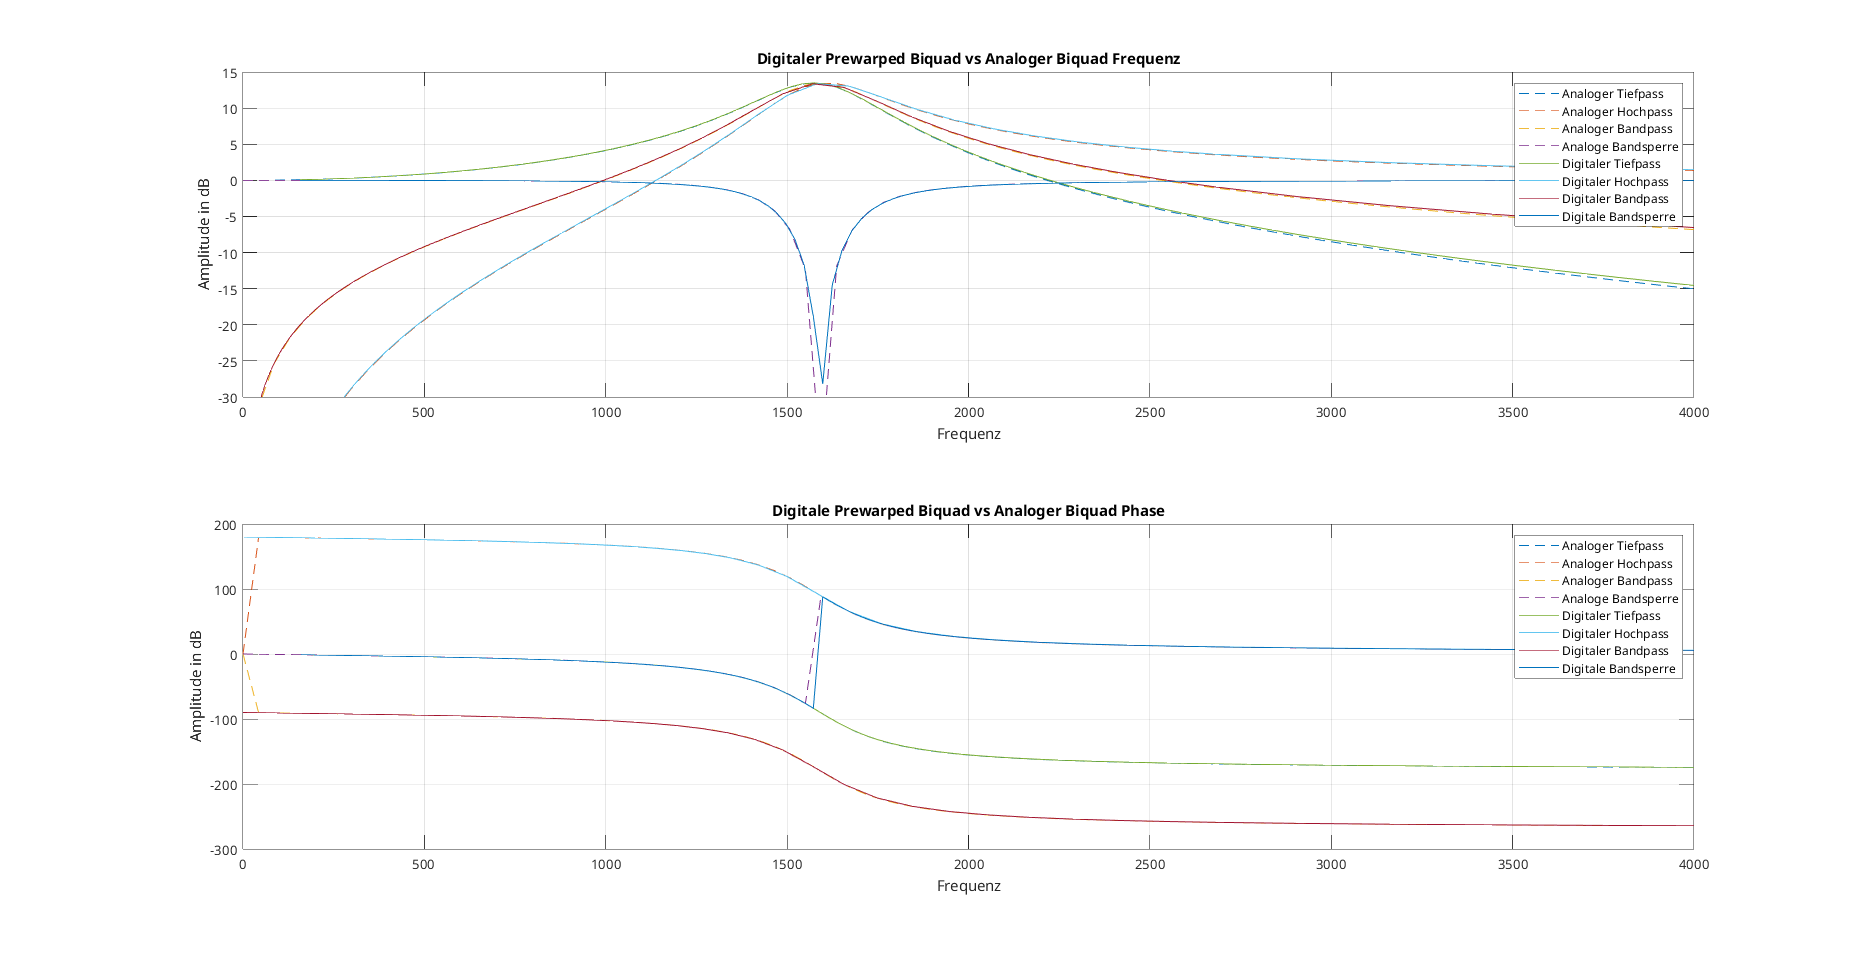
<figcaption aria-hidden="true">Vergleich zwischen anaolgen und digitalen (Prewarped) Frequenz- und Phasengang</figcaption>
</figure>